# **Question 1 : Datasheet Loading**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- Load Data ---
s1 = pd.read_csv('/home/banibrata/Desktop/s1.txt', header=None, names=['x', 'y'], sep='\s+')
test = pd.read_csv('/home/banibrata/Desktop/test.txt', header=None, names=['x', 'y'], sep='\s+')

print("S1 Data shape:", s1.shape)
print("Test Data shape:", test.shape)

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24903/1896922106.py:9: SyntaxWarning: invalid escape sequence '\s'
  s1 = pd.read_csv('/home/banibrata/Desktop/s1.txt', header=None, names=['x', 'y'], sep='\s+')
/tmp/ipykernel_24903/1896922106.py:10: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv('/home/banibrata/Desktop/test.txt', header=None, names=['x', 'y'], sep='\s+')


S1 Data shape: (5000, 2)
Test Data shape: (8, 2)


# **Question 1 : (2,3)**

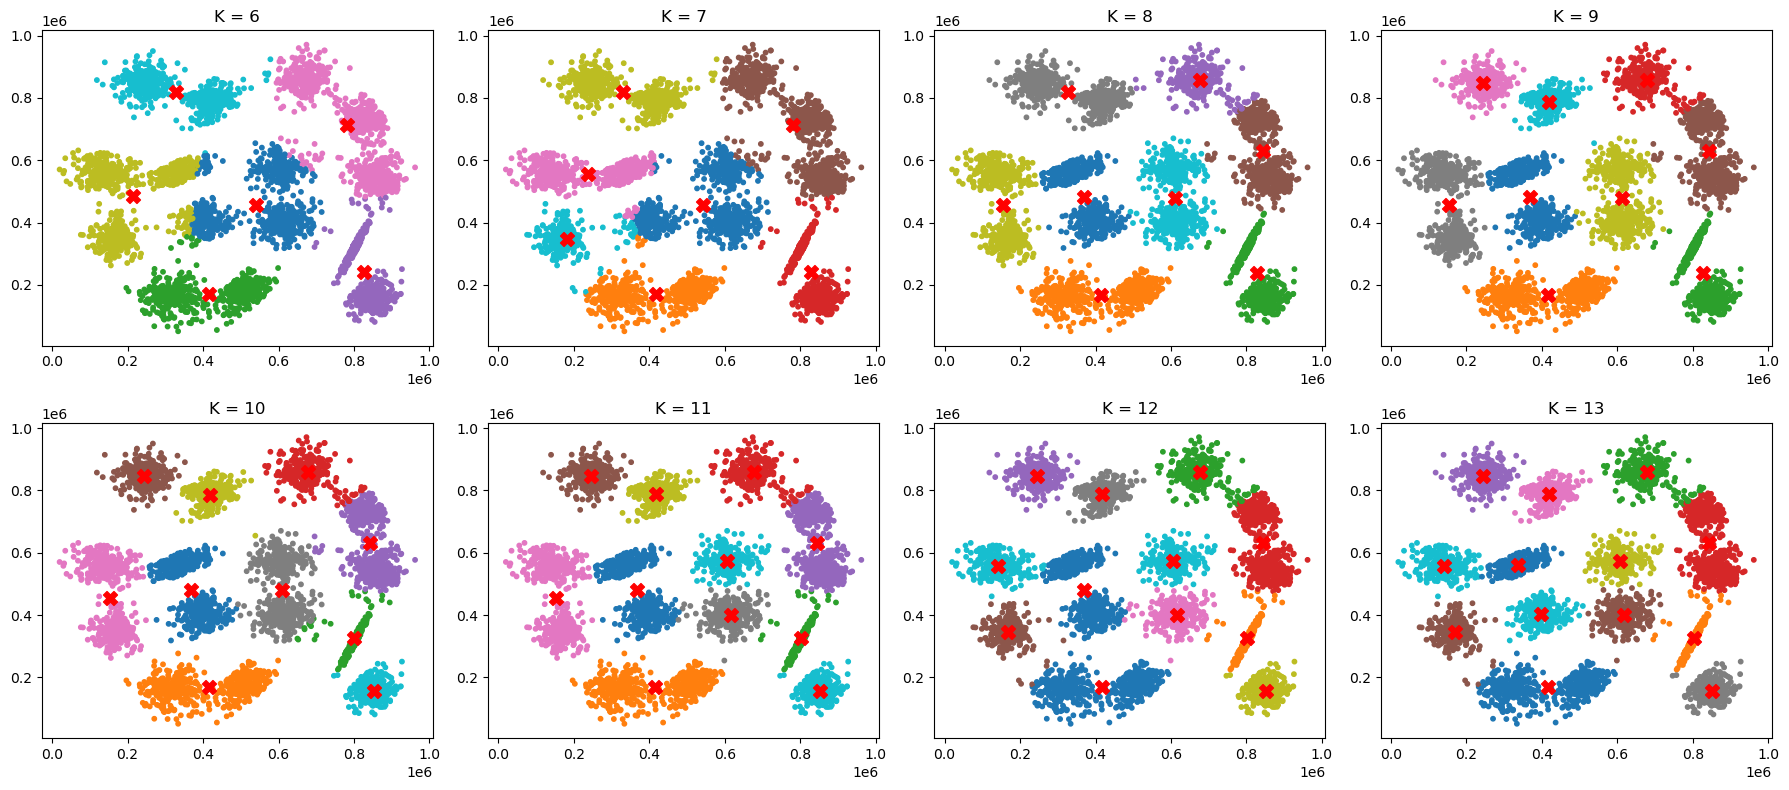

In [2]:
K_values = range(6, 14)
fig, axs = plt.subplots(2, 4, figsize=(18, 8))
axs = axs.flatten()

cluster_results = {}
for i, K in enumerate(K_values):
    kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(s1)
    centers = kmeans.cluster_centers_
    
    cluster_results[K] = (labels, centers)
    axs[i].scatter(s1['x'], s1['y'], c=labels, s=10, cmap='tab10')
    axs[i].scatter(centers[:,0], centers[:,1], c='red', marker='X', s=100)
    axs[i].set_title(f'K = {K}')

plt.tight_layout()
plt.show()

# **Question 1 : (4)**

In [3]:
print("""\nObservations when K increases from 6 to 13:
- For smaller K, clusters are large and coarse; boundaries merge diverse groups.
- As K increases, clusters become more refined and compact.
- Beyond a certain K (e.g., >10), over-segmentation occurs, splitting naturally cohesive groups.
- Visual inspection shows around 9–10 may give balanced granularity.
""")


Observations when K increases from 6 to 13:
- For smaller K, clusters are large and coarse; boundaries merge diverse groups.
- As K increases, clusters become more refined and compact.
- Beyond a certain K (e.g., >10), over-segmentation occurs, splitting naturally cohesive groups.
- Visual inspection shows around 9–10 may give balanced granularity.



# **Question 1 : (5)**

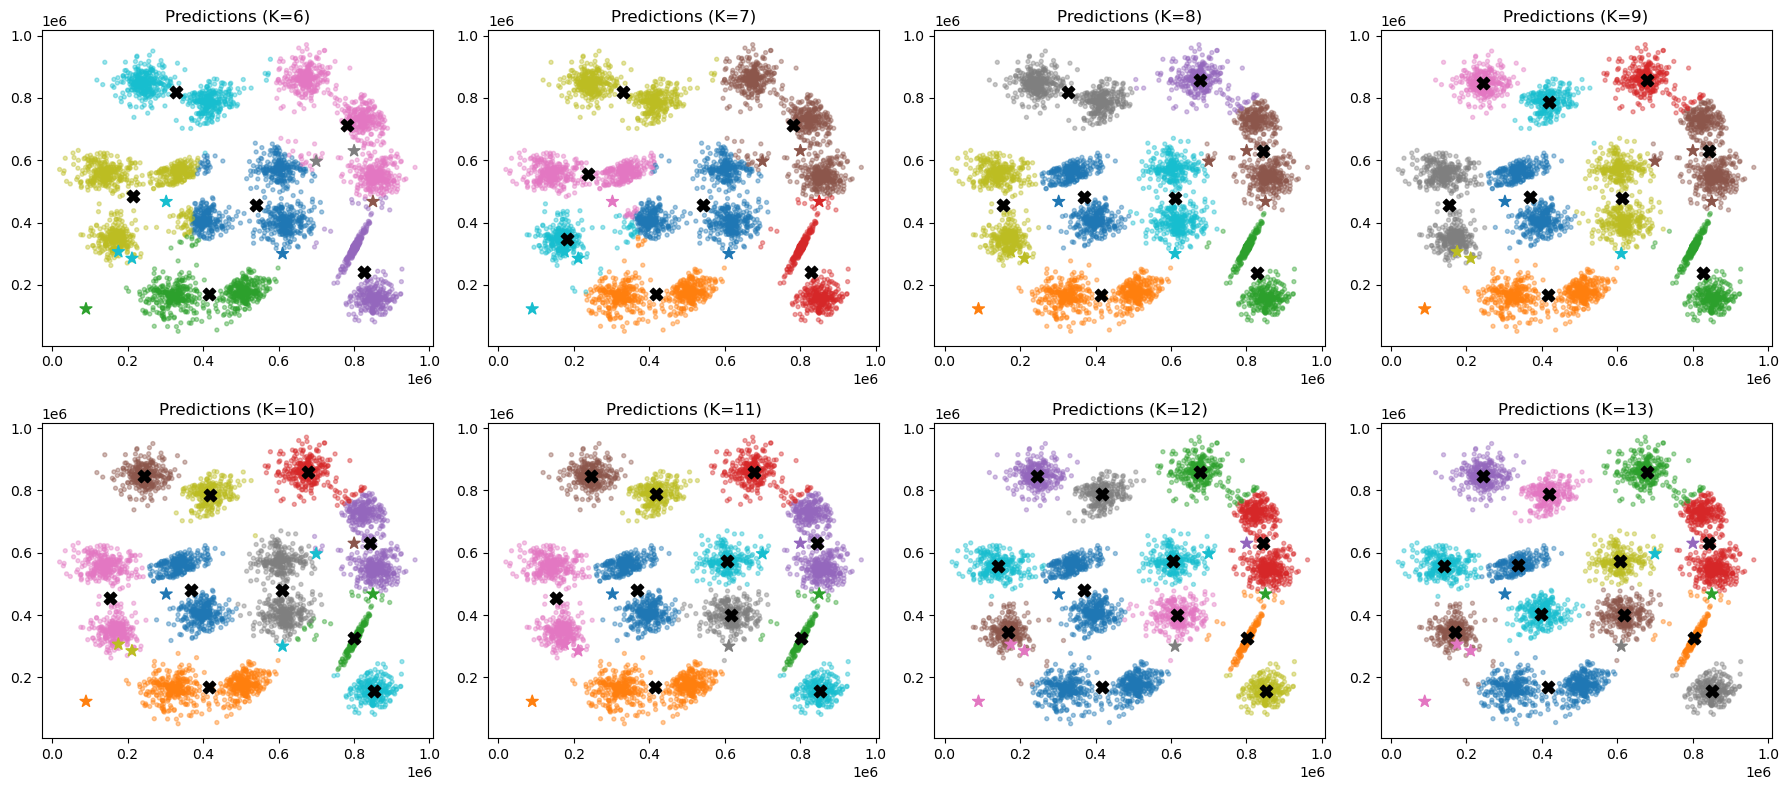

In [4]:
fig, axs = plt.subplots(2, 4, figsize=(18, 8))
axs = axs.flatten()

for i, K in enumerate(K_values):
    kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42).fit(s1)
    test_labels = kmeans.predict(test)
    axs[i].scatter(s1['x'], s1['y'], c=kmeans.labels_, s=8, alpha=0.4, cmap='tab10')
    axs[i].scatter(test['x'], test['y'], c=test_labels, marker='*', s=80, cmap='tab10')
    axs[i].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='black', marker='X', s=80)
    axs[i].set_title(f'Predictions (K={K})')

plt.tight_layout()
plt.show()

# **Question 1 : (6)**

In [5]:
print("""Observations:
- Predicted test points mostly align near major cluster centers.
- Increasing K leads to finer discrimination between nearby test points.
- For large K, cluster assignment becomes unstable due to small cluster radii.
""")

Observations:
- Predicted test points mostly align near major cluster centers.
- Increasing K leads to finer discrimination between nearby test points.
- For large K, cluster assignment becomes unstable due to small cluster radii.



# **Question 1 : (7,8)**

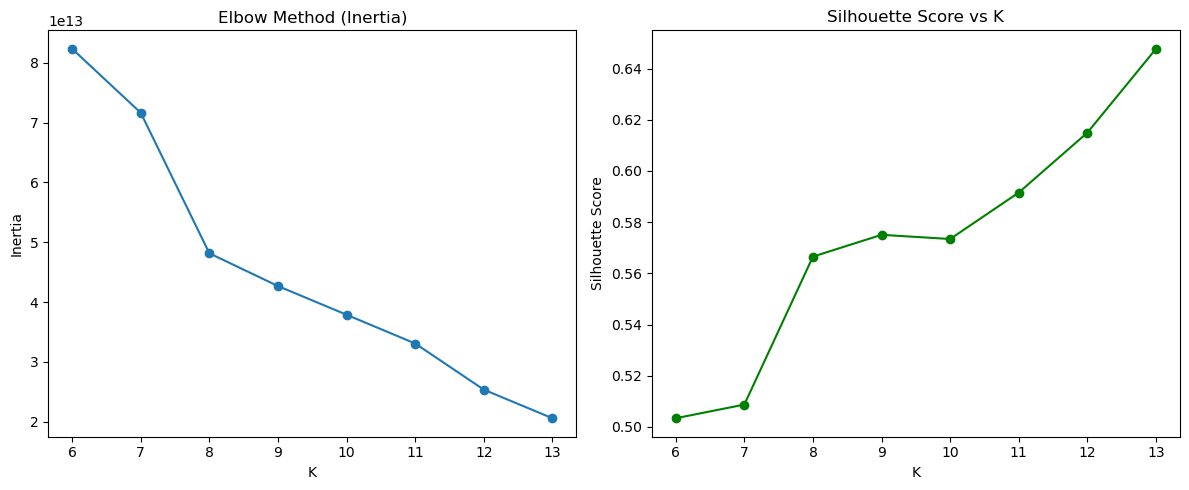

Best K based on silhouette score: 13


In [6]:
inertia = []
sil_scores = []
for K in K_values:
    kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42).fit(s1)
    inertia.append(kmeans.inertia_)
    sil = silhouette_score(s1, kmeans.labels_)
    sil_scores.append(sil)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_values, inertia, '-o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('K')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(K_values, sil_scores, '-o', color='green')
plt.title('Silhouette Score vs K')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_K = K_values[np.argmax(sil_scores)]
print(f"Best K based on silhouette score: {best_K}")

# **Question 1 : (9,10)**

In [7]:
scaler = StandardScaler()
s1_scaled = pd.DataFrame(scaler.fit_transform(s1), columns=['x', 'y'])
print('\nAfter normalization:')
print('Mean:', s1_scaled.mean().values)
print('Variance:', s1_scaled.var().values)


After normalization:
Mean: [-6.82121026e-17  4.54747351e-17]
Variance: [1.00020004 1.00020004]


# **Question 1 : (11,12)**

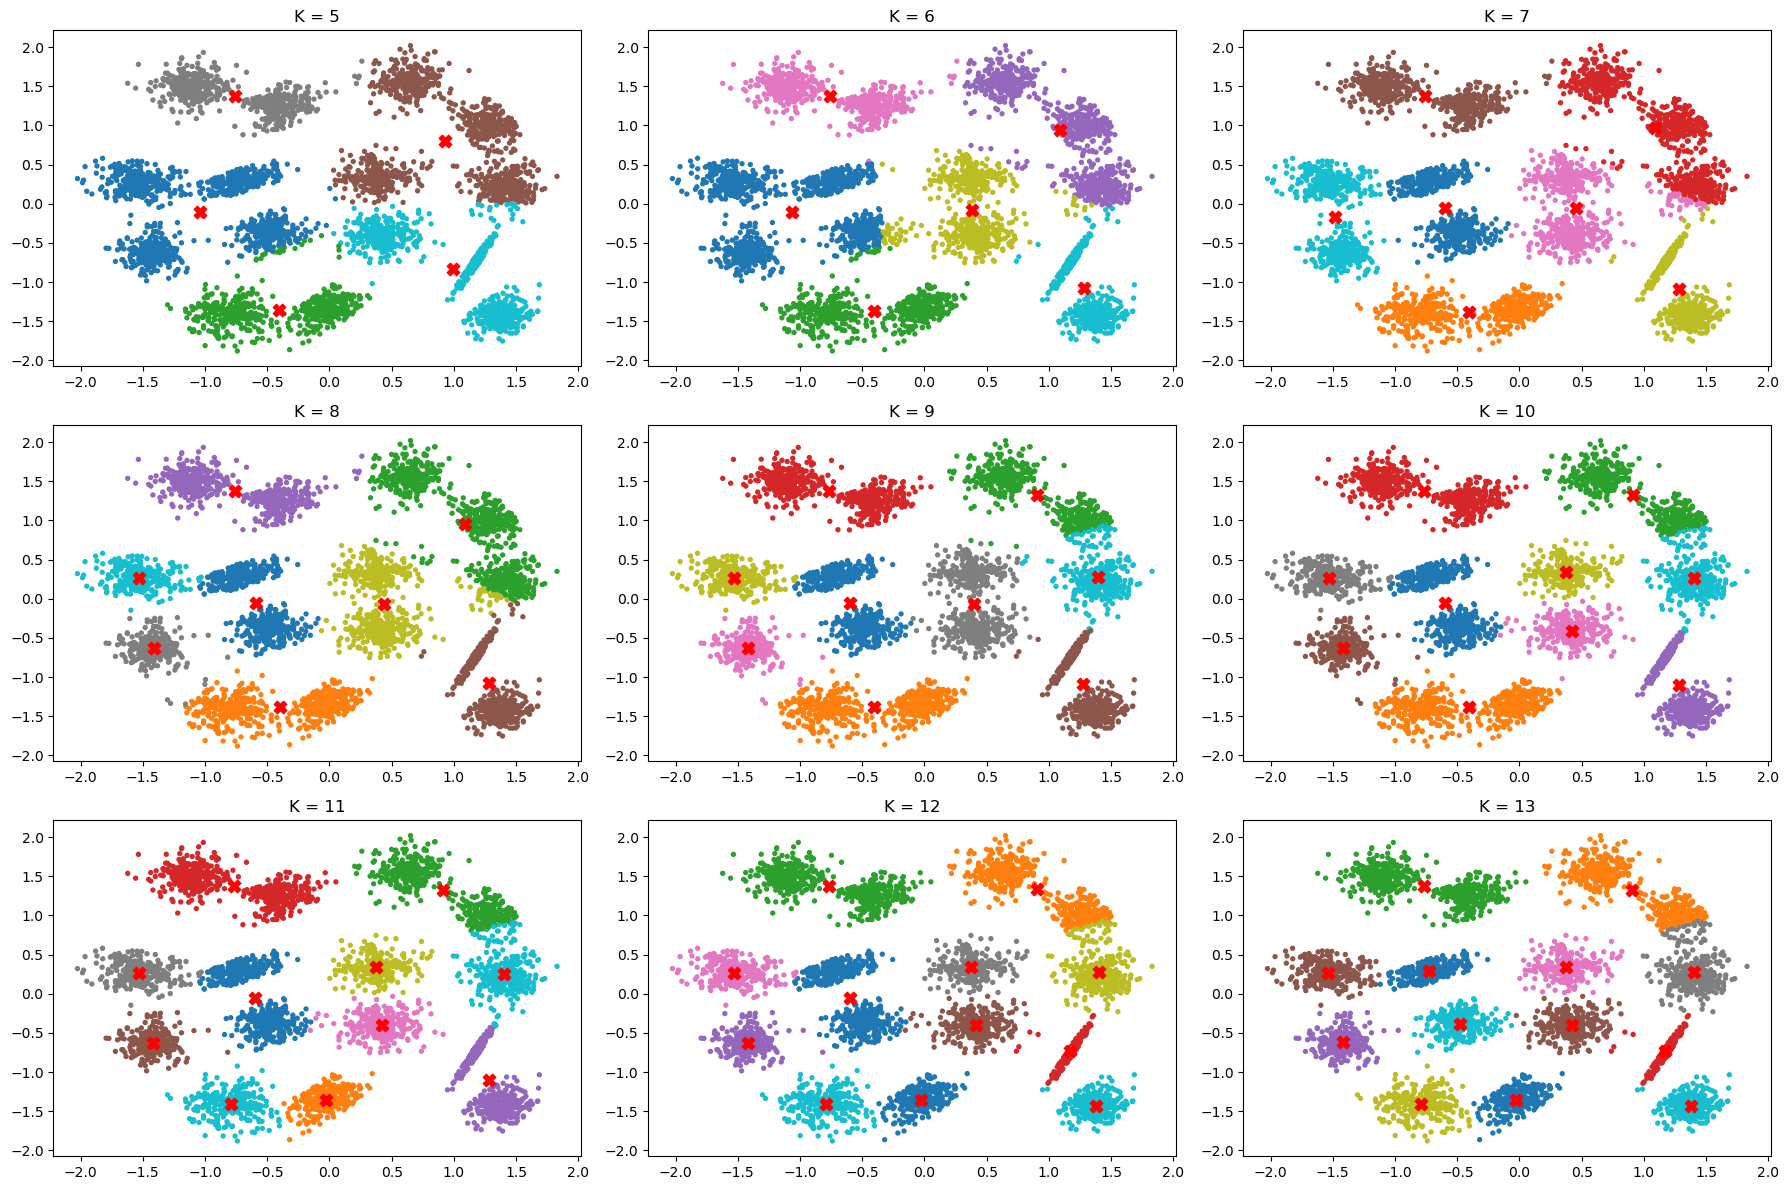

In [8]:
K_values2 = range(5, 14)
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
axs = axs.flatten()

cluster_results_scaled = {}
for i, K in enumerate(K_values2):
    kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(s1_scaled)
    centers = kmeans.cluster_centers_
    cluster_results_scaled[K] = (labels, centers)
    axs[i].scatter(s1_scaled['x'], s1_scaled['y'], c=labels, s=8, cmap='tab10')
    axs[i].scatter(centers[:,0], centers[:,1], c='red', marker='X', s=80)
    axs[i].set_title(f'K = {K}')

plt.tight_layout()
plt.show()

# **Question 1 : (13)**

In [9]:
print("""Observations after normalization:
- Scaling made clusters isotropic, removing dominance of large-scale coordinates.
- Normalized data shows clearer circular clusters.""")

Observations after normalization:
- Scaling made clusters isotropic, removing dominance of large-scale coordinates.
- Normalized data shows clearer circular clusters.


# **Question 1 : (14)**

In [10]:
print("""Explanation:
The test data must be normalized using the same scaler fitted on the training data (S1.txt)
so that both share the same scale for clustering prediction.""")

Explanation:
The test data must be normalized using the same scaler fitted on the training data (S1.txt)
so that both share the same scale for clustering prediction.


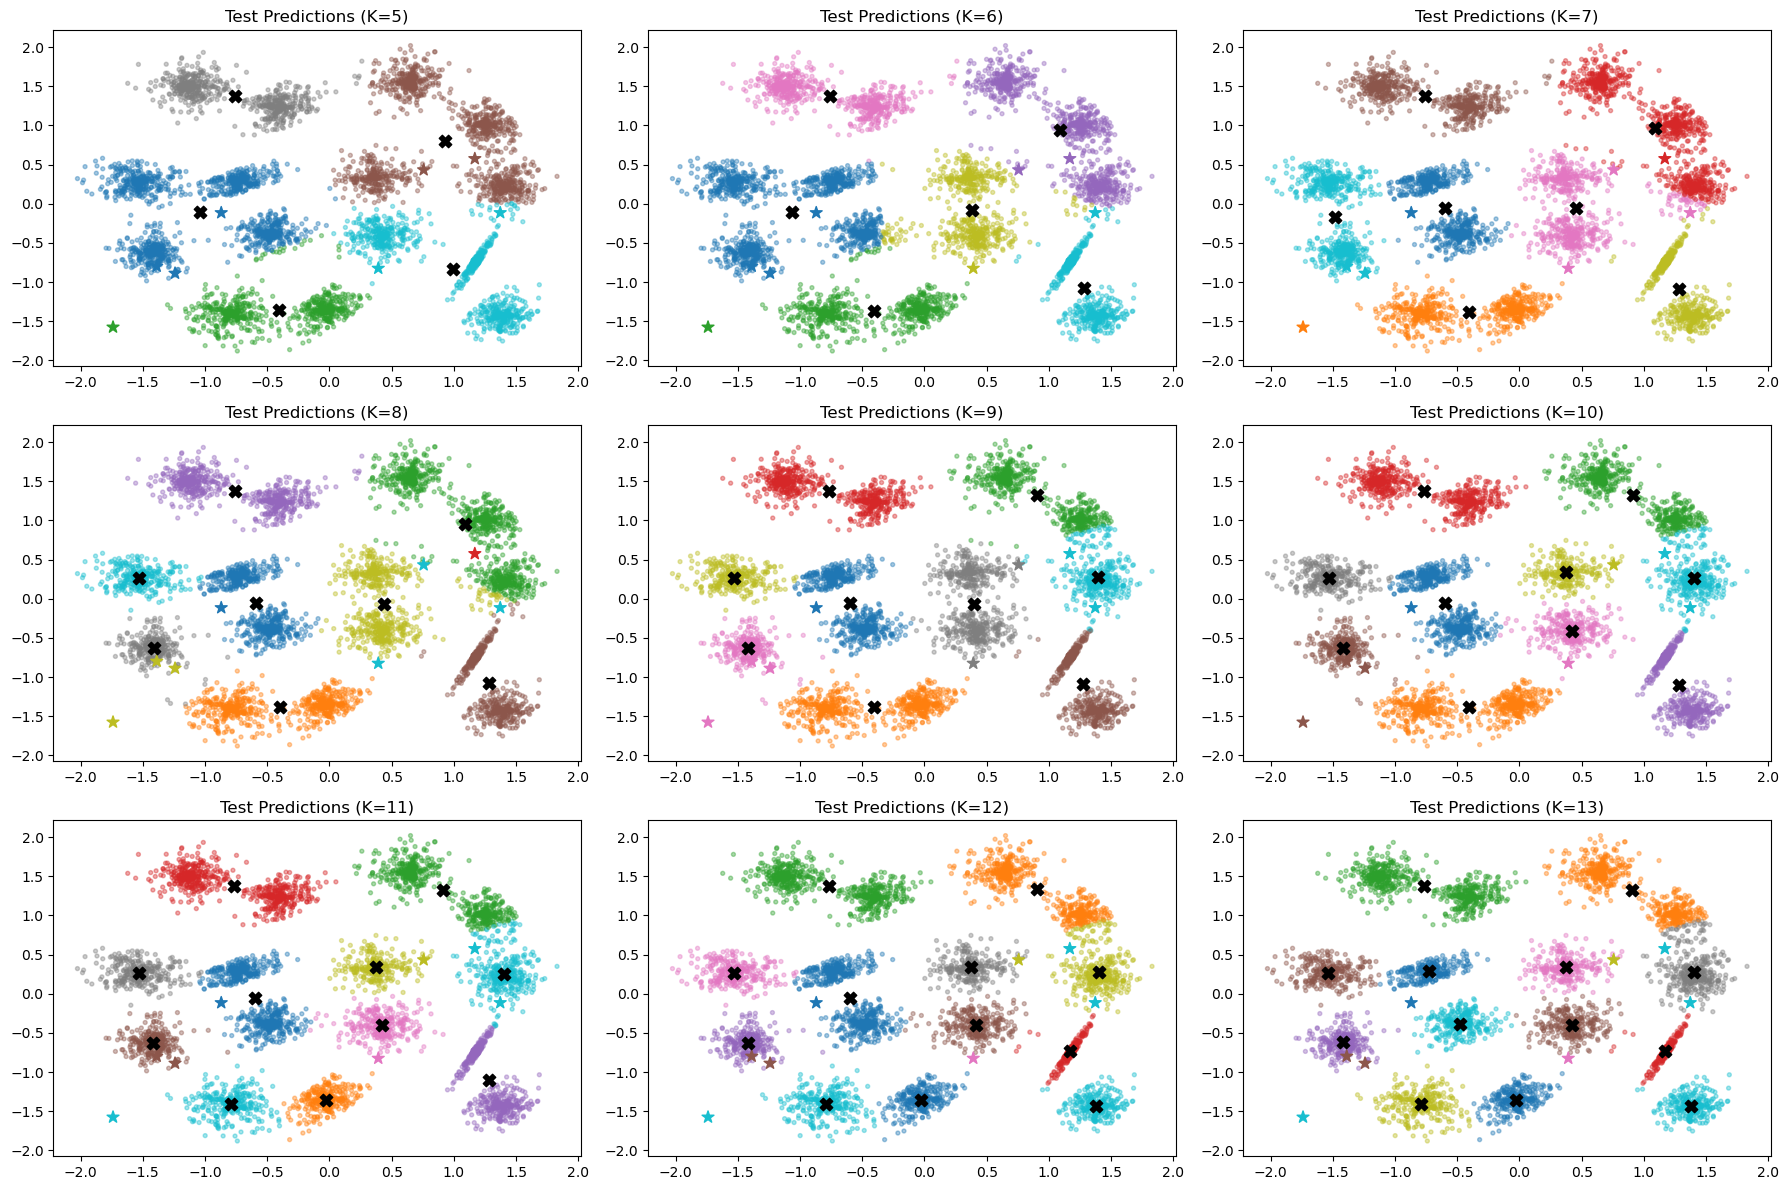

In [11]:
test_scaled = pd.DataFrame(scaler.transform(test), columns=['x', 'y'])
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
axs = axs.flatten()

for i, K in enumerate(K_values2):
    kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42).fit(s1_scaled)
    test_labels = kmeans.predict(test_scaled)
    axs[i].scatter(s1_scaled['x'], s1_scaled['y'], c=kmeans.labels_, s=8, alpha=0.4, cmap='tab10')
    axs[i].scatter(test_scaled['x'], test_scaled['y'], c=test_labels, marker='*', s=80, cmap='tab10')
    axs[i].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='black', marker='X', s=80)
    axs[i].set_title(f'Test Predictions (K={K})')

plt.tight_layout()
plt.show()

# **Question 1 : (15)**

In [12]:
print("""
Observations (Normalized test predictions):
- Normalized test data integrates smoothly with scaled training data.
- Predictions are more consistent across K values than before normalization.
- Clusters appear balanced and less biased toward large-magnitude features.
""")


Observations (Normalized test predictions):
- Normalized test data integrates smoothly with scaled training data.
- Predictions are more consistent across K values than before normalization.
- Clusters appear balanced and less biased toward large-magnitude features.



# **Question 1 : (16)**

In [13]:
inertia2, sil_scores2 = [], []
for K in K_values2:
    kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42).fit(s1_scaled)
    inertia2.append(kmeans.inertia_)
    sil_scores2.append(silhouette_score(s1_scaled, kmeans.labels_))

best_K_scaled = K_values2[sil_scores2.index(max(sil_scores2))]
print(f"Best K (normalized data): {best_K_scaled}")

Best K (normalized data): 13


# **Question 1 : (17,18,19)**

In [14]:
print("""
Q17. Differences (without vs with normalization):
- Without normalization: x, y values differ in scale, biasing distance computation.
- With normalization: Each feature contributes equally; cluster boundaries are fairer.

Q18. Differences during prediction:
- Without normalization: Predictions skewed toward high-magnitude regions.
- With normalization: Predictions align better with actual cluster centers.
- Test labels remain consistent across nearby K values, showing improved robustness.

Q19. When normalization helps:
- When features have different magnitudes (e.g., age vs. income).
- Prevents one feature from dominating the distance metric in K-Means.
- Also helps in PCA, regression, and neural networks.
""")


Q17. Differences (without vs with normalization):
- Without normalization: x, y values differ in scale, biasing distance computation.
- With normalization: Each feature contributes equally; cluster boundaries are fairer.

Q18. Differences during prediction:
- Without normalization: Predictions skewed toward high-magnitude regions.
- With normalization: Predictions align better with actual cluster centers.
- Test labels remain consistent across nearby K values, showing improved robustness.

Q19. When normalization helps:
- When features have different magnitudes (e.g., age vs. income).
- Prevents one feature from dominating the distance metric in K-Means.
- Also helps in PCA, regression, and neural networks.

